# Ising dataset (baseline simulator)

Build graphs from `../../tutorials/data/ising_dataset/train`, train the graph-Transformer QEM model (`QEMGraphTransformer`), train a per-qubit Random Forest baseline on the same split, and compare both against the ideal expectation values on the validation split.

Unlike the Brisbane hardware notebooks, this dataset already carries `ideal_exp_value` / `noisy_exp_values` per circuit, so there is no ZNE-derivation step -- labels come straight from the data.

In [1]:
import sys, os, json, importlib, random, pickle
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from qiskit.dagcircuit import DAGOpNode

# lightcone.assign_moments (dag.layers()-based) silently drops some
# nodes (e.g. barriers) in some qiskit versions; use a topological-order
# version instead, matching 01_build_graphs.ipynb's fix.
def assign_moments_topo(dag):
    moments = {}
    for node in dag.topological_op_nodes():
        preds = [e.node for e in dag.predecessors(node)
                 if hasattr(e, "node") and isinstance(e.node, DAGOpNode)]
        moments[node] = 0 if not preds else 1 + max(moments[p] for p in preds)
    return moments

import lightcone
lightcone.assign_moments = assign_moments_topo
import circuits_to_graph
importlib.reload(circuits_to_graph)
import dataset
importlib.reload(dataset)

from schemas import ConvertConfig
from sim_data_utils import (
    build_labels_csv, attach_labels_and_noisy_exact, build_measured_qubits_map,
    stage_flat_dir, convert_qasm_json_dir_to_pk, load_circuit_label_lists,
)
from data_utils import load_graphs, build_loaders
from torch_geometric.loader import DataLoader
from train_loop import train, evaluate
from model import QEMGraphTransformer
from mlp import encode_data_v2_ecr
from sklearn.ensemble import RandomForestRegressor

In [2]:
DATASET_NAME = 'ising_dataset'
RAW_TRAIN_DIR = '../../tutorials/data/ising_dataset/train'
RAW_VAL_DIR = '../../tutorials/data/ising_dataset/val'  # None if no usable val split exists
RUN_DIR = f"runs/{DATASET_NAME}"
os.makedirs(RUN_DIR, exist_ok=True)

In [3]:
TRAIN_DIR = RAW_TRAIN_DIR
VAL_DIR = RAW_VAL_DIR

**Per-circuit measured-qubit map.** `ideal_exp_value[i]` / `noisy_exp_values[i]` are indexed by *classical-bit* order, but neither the set nor the order of physically measured qubits is fixed across circuits here -- it shifts across Trotter steps and even varies circuit-to-circuit within a step. Passing a flat `[0, 1, 2, 3]` as the measured-qubit list would silently mislabel the graph's lightcone columns (and for many circuits leaves a 'measured' column with an empty lightcone -> NaN loss). So instead we derive the correct per-circuit qubit order straight from each circuit's own `measure` instructions.

In [4]:
def build_split(input_dir, split):
    measured_map_json = build_measured_qubits_map(
        input_dir, f"{RUN_DIR}/measured_map_{split}.json", file_extensions=[".pk"],
    )
    cfg = ConvertConfig(
        input_dir=input_dir, split=split,
        output_path=f"{RUN_DIR}/processed/graphs_{split}.pt",
        measured_qubits=None, measured_map_json=measured_map_json,
        max_params=2, verbose=True,
        file_extensions=[".pk"],
    )
    dataset.convert_folder_to_pt(cfg)
    build_labels_csv(input_dir, f"{RUN_DIR}/labels_{split}.csv", file_extensions=[".pk"])
    graphs = load_graphs(cfg.output_path)
    graphs, M = attach_labels_and_noisy_exact(graphs, f"{RUN_DIR}/labels_{split}.csv")
    return graphs, M

train_graphs, M = build_split(TRAIN_DIR, "train")
print(f"train graphs: {len(train_graphs)} | M={M}")

if VAL_DIR is not None:
    val_graphs, M_val = build_split(VAL_DIR, "val")
    assert M_val == M
    print(f"val graphs: {len(val_graphs)} | M={M_val}")
    train_loader = DataLoader(train_graphs, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_graphs, batch_size=16, shuffle=False)
else:
    print("No usable val split for this dataset; using an internal 80/20 split of train.")
    train_loader, val_loader = build_loaders(train_graphs, batch_size=16, val_frac=0.2, seed=42)

Processing...


Converting train circuits:   0%|          | 0/5000 [00:00<?, ?circuit/s]

Done!


train graphs: 5000 | M=4


Processing...


Converting val circuits:   0%|          | 0/2000 [00:00<?, ?circuit/s]

Done!


val graphs: 2000 | M=4


In [6]:
model_cfg = dict(d_model=128, layers=3, heads=4, dropout=0.1, use_noisy=True)
net, hist = train(model_cfg, (train_loader, val_loader), epochs=100, lr=1e-3, wd=1e-4,
                   patience=30, device='cuda',
                   best_ckpt_path=f"{RUN_DIR}/best_qem_graph_transformer.pt")
total_params = sum(p.numel() for p in net.parameters())
print("Total params:", total_params)

Epoch 001 | train 0.0294 | val 0.0030 | MAE 0.0615
Epoch 002 | train 0.0027 | val 0.0010 | MAE 0.0327
Epoch 003 | train 0.0012 | val 0.0005 | MAE 0.0250
Epoch 004 | train 0.0008 | val 0.0002 | MAE 0.0157
Epoch 005 | train 0.0006 | val 0.0003 | MAE 0.0205
Epoch 006 | train 0.0006 | val 0.0003 | MAE 0.0202
Epoch 007 | train 0.0006 | val 0.0002 | MAE 0.0174
Epoch 008 | train 0.0005 | val 0.0002 | MAE 0.0165
Epoch 009 | train 0.0005 | val 0.0003 | MAE 0.0198
Epoch 010 | train 0.0005 | val 0.0003 | MAE 0.0195
Epoch 011 | train 0.0005 | val 0.0003 | MAE 0.0182
Epoch 012 | train 0.0005 | val 0.0004 | MAE 0.0248
Epoch 013 | train 0.0005 | val 0.0006 | MAE 0.0271
Epoch 014 | train 0.0005 | val 0.0002 | MAE 0.0145
Epoch 015 | train 0.0004 | val 0.0003 | MAE 0.0204
Epoch 016 | train 0.0005 | val 0.0002 | MAE 0.0158
Epoch 017 | train 0.0005 | val 0.0002 | MAE 0.0152
Epoch 018 | train 0.0004 | val 0.0002 | MAE 0.0151
Epoch 019 | train 0.0004 | val 0.0002 | MAE 0.0155
Epoch 020 | train 0.0004 | val 

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
net.to(device)

@torch.no_grad()
def collect_pred_target_noisy(loader, model, M, device):
    model.eval()
    P, Y, N = [], [], []
    for batch in loader:
        batch = batch.to(device)
        y_hat = model(batch)
        P.append(y_hat.detach().cpu()); Y.append(batch.y.detach().cpu()); N.append(batch.noisy_z.detach().cpu())
    return torch.cat(P).view(-1, M), torch.cat(Y).view(-1, M), torch.cat(N).view(-1, M)

P, Y, N = collect_pred_target_noisy(val_loader, net, M, device)
gnn_mae = (P - Y).abs().mean(dim=0).tolist()
print("Per-qubit MAE (GNN):", gnn_mae)

Per-qubit MAE (GNN): [0.01375183742493391, 0.014175061136484146, 0.012496392242610455, 0.011124884709715843]


## Random Forest baseline

Trained/evaluated on the *same* train/val circuits as the GNN (matched by `circuit_path`).

In [8]:
train_paths_set = {g.circuit_path for g in train_loader.dataset}
val_paths_set = {g.circuit_path for g in val_loader.dataset}

def gather_split(input_dir, wanted_paths):
    paths, circuits, ideal, noisy = load_circuit_label_lists(input_dir, file_extensions=[".pk"])
    keep = [i for i, p in enumerate(paths) if p in wanted_paths]
    return [circuits[i] for i in keep], [ideal[i] for i in keep], [noisy[i] for i in keep]

train_circuits, train_ideal, train_noisy = gather_split(TRAIN_DIR, train_paths_set)
val_source_dir = VAL_DIR if VAL_DIR is not None else TRAIN_DIR
val_circuits, val_ideal, val_noisy = gather_split(val_source_dir, val_paths_set)
print(f"RF train circuits: {len(train_circuits)} | RF val circuits: {len(val_circuits)}")

RF train circuits: 5000 | RF val circuits: 2000


In [9]:
X_train, y_train = encode_data_v2_ecr(train_circuits, train_ideal, train_noisy, obs_size=M, two_q_gate='cx')
X_val, y_val = encode_data_v2_ecr(val_circuits, val_ideal, val_noisy, obs_size=M, two_q_gate='cx')

rf_models = []
for q in range(M):
    rfr = RandomForestRegressor(n_estimators=100, n_jobs=-1)
    rfr.fit(X_train.numpy(), y_train.numpy()[:, q])
    rf_models.append(rfr)
    print(f"RF trained for qubit {q}")

rf_preds = np.stack([m.predict(X_val.numpy()) for m in rf_models], axis=1)
rf_mae = np.abs(rf_preds - y_val.numpy()).mean(axis=0).tolist()
print("Per-qubit MAE (RF):", rf_mae)

RF trained for qubit 0
RF trained for qubit 1
RF trained for qubit 2
RF trained for qubit 3
Per-qubit MAE (RF): [0.008959388088863058, 0.008989618841059, 0.008987581825963717, 0.008530926808215726]


## Comparison: unmitigated noisy vs RF vs GNN

In [10]:
noisy_np = N.numpy()
gnn_np = P.numpy()
ideal_np = Y.numpy()

def rmse_per_qubit(pred, ideal):
    return np.sqrt(((pred - ideal) ** 2).mean(axis=0))

rmse_noisy = rmse_per_qubit(noisy_np, ideal_np)
rmse_gnn = rmse_per_qubit(gnn_np, ideal_np)
rmse_rf = rmse_per_qubit(rf_preds, y_val.numpy())

results = pd.DataFrame({
    "qubit": [f"q{q}" for q in range(M)],
    "rmse_noisy": rmse_noisy,
    "rmse_rf": rmse_rf,
    "rmse_gnn": rmse_gnn,
})
overall = pd.DataFrame([{"qubit": "overall", "rmse_noisy": rmse_noisy.mean(),
                        "rmse_rf": rmse_rf.mean(), "rmse_gnn": rmse_gnn.mean()}])
results = pd.concat([results, overall], ignore_index=True)
print(results)

results.to_csv(f"{RUN_DIR}/comparison_results.csv", index=False)
with open(f"{RUN_DIR}/comparison_results.json", "w") as f:
    json.dump({
        "dataset": DATASET_NAME,
        "rmse_noisy": rmse_noisy.tolist(), "rmse_rf": rmse_rf.tolist(), "rmse_gnn": rmse_gnn.tolist(),
        "n_train": len(train_loader.dataset), "n_val": len(val_loader.dataset),
    }, f, indent=2)

     qubit  rmse_noisy   rmse_rf  rmse_gnn
0       q0    0.150565  0.011793  0.017845
1       q1    0.121343  0.011887  0.018056
2       q2    0.053847  0.011837  0.016079
3       q3    0.039224  0.011269  0.014254
4  overall    0.091245  0.011696  0.016559


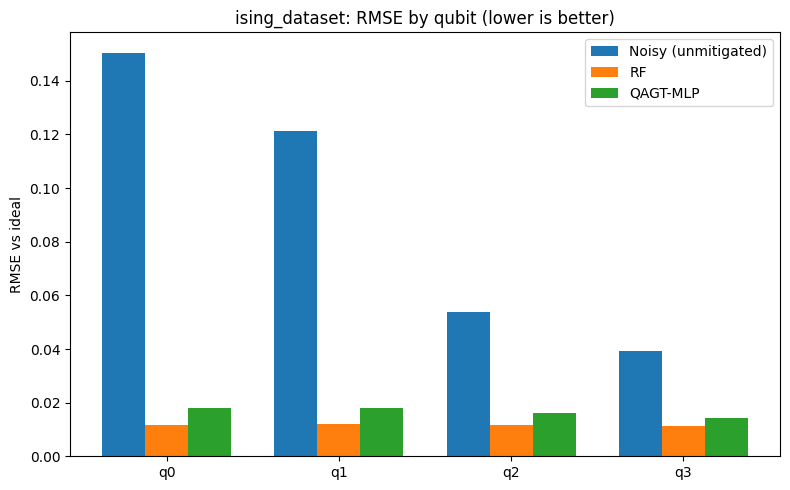

In [12]:
x = np.arange(M)
width = 0.25
plt.figure(figsize=(8, 5))
plt.bar(x - width, rmse_noisy, width, label="Noisy (unmitigated)")
plt.bar(x, rmse_rf, width, label="RF")
plt.bar(x + width, rmse_gnn, width, label="QAGT-MLP")
plt.xticks(x, [f"q{q}" for q in range(M)])
plt.ylabel("RMSE vs ideal")
plt.title(f"{DATASET_NAME}: RMSE by qubit (lower is better)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{RUN_DIR}/rmse_comparison.png")
plt.show()